# Tuning objective and coefficient comparison

Hypothesis: tuning the same model's hyperparameters against different metrics (accuracy vs ROC-AUC vs log loss) yields different fitted models, not just different scores.

A single synthetic, moderately separated, moderately imbalanced dataset is used to tune three `LogisticRegression` models via grid search: one optimising accuracy, one ROC-AUC, and one log loss. The resulting coefficients are then compared directly, and all three models are scored with accuracy, ROC-AUC, and log loss on a common held-out test set.

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Create synthetic data

`class_sep=0.7` gives moderate class overlap, and `weights=[0.6, 0.4]` gives a mild 60:40 imbalance ratio.

In [2]:
random_state = 42

X, y = make_classification(
    n_samples=5000,
    n_features=10,
    n_informative=3,
    n_redundant=5,
    n_repeated=0,
    n_classes=2,
    flip_y=0,
    class_sep=0.6,
    weights=[0.7, 0.3],
    random_state=random_state,
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=random_state,
)

print("Train class balance:", np.bincount(y_train) / len(y_train))
print("Test class balance:", np.bincount(y_test) / len(y_test))

Train class balance: [0.7 0.3]
Test class balance: [0.7 0.3]


## Tune Logistic Regression on accuracy vs ROC-AUC vs log loss

Same estimator, same parameter grid, same folds -- the only thing that differs between the three grid searches is the `scoring` argument. Log loss is minimised, so it's tuned via the `neg_log_loss` scorer (`GridSearchCV` always maximises the score it's given).

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

param_grid = {
    "clf__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "clf__l1_ratio": [0, 0.2, 0.5, 0.7, 1],
    "clf__solver": ["saga"],
}

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=10000, random_state=random_state)),
])

scoring_metrics = ["accuracy", "roc_auc", "neg_log_loss"]
display_name = {"accuracy": "accuracy", "roc_auc": "roc_auc", "neg_log_loss": "log_loss"}
tuned_models = {}

for scoring in scoring_metrics:
    search = GridSearchCV(pipe, param_grid, scoring=scoring, cv=cv, n_jobs=-1)
    search.fit(X_train, y_train)
    tuned_models[scoring] = search
    best_score = -search.best_score_ if scoring == "neg_log_loss" else search.best_score_
    print(f"Best params optimising {display_name[scoring]}: {search.best_params_}")
    print(f"Best CV {display_name[scoring]}: {best_score:.4f}\n")

Best params optimising accuracy: {'clf__C': 0.01, 'clf__l1_ratio': 0.5, 'clf__solver': 'saga'}
Best CV accuracy: 0.8331

Best params optimising roc_auc: {'clf__C': 0.001, 'clf__l1_ratio': 0, 'clf__solver': 'saga'}
Best CV roc_auc: 0.8626

Best params optimising log_loss: {'clf__C': 0.1, 'clf__l1_ratio': 1, 'clf__solver': 'saga'}
Best CV log_loss: 0.4033



## Coefficient uncertainty across folds

A single fit gives a point estimate, not a sense of how stable that estimate is. To get uncertainty, each model is refit on the same 5 CV folds used by the grid search, at its own best hyperparameters, and the coefficients are collected per fold. Their mean and std across folds are what get compared and plotted.

In [4]:
coef_stats = {}

for scoring, search in tuned_models.items():
    best_pipe = clone(pipe).set_params(**search.best_params_)
    fold_results = cross_validate(
        best_pipe, X_train, y_train,
        cv=cv, return_estimator=True, n_jobs=-1,
    )
    fold_coefs = np.array([
        est.named_steps["clf"].coef_.ravel() for est in fold_results["estimator"]
    ])
    fold_intercepts = np.array([
        est.named_steps["clf"].intercept_[0] for est in fold_results["estimator"]
    ])
    coef_stats[scoring] = {
        "coef_mean": fold_coefs.mean(axis=0),
        "coef_std": fold_coefs.std(axis=0),
        "intercept_mean": fold_intercepts.mean(),
        "intercept_std": fold_intercepts.std(),
    }
    print(
        f"{display_name[scoring]}: intercept = {coef_stats[scoring]['intercept_mean']:.4f} "
        f"+/- {coef_stats[scoring]['intercept_std']:.4f}"
    )

accuracy: intercept = -1.1366 +/- 0.0087
roc_auc: intercept = -0.9667 +/- 0.0023
log_loss: intercept = -1.2637 +/- 0.0144


## Compare coefficients

Coefficients from all three tuned models, side by side, plus how far each feature's mean coefficient spreads across the three tuning objectives.

In [5]:
coef_df = pd.DataFrame({"feature": [f"x{i}" for i in range(X.shape[1])]})
for scoring in scoring_metrics:
    name = display_name[scoring]
    coef_df[f"coef_{name}_mean"] = coef_stats[scoring]["coef_mean"]
    coef_df[f"coef_{name}_std"] = coef_stats[scoring]["coef_std"]

mean_cols = [f"coef_{display_name[scoring]}_mean" for scoring in scoring_metrics]
coef_df["mean_spread"] = coef_df[mean_cols].max(axis=1) - coef_df[mean_cols].min(axis=1)
coef_df = coef_df.sort_values("mean_spread", ascending=False).reset_index(drop=True)

corr_matrix = pd.DataFrame(
    np.corrcoef(coef_df[mean_cols].to_numpy(), rowvar=False),
    index=[display_name[s] for s in scoring_metrics],
    columns=[display_name[s] for s in scoring_metrics],
)
print("Correlation between mean coefficient vectors:")
print(corr_matrix.round(4))

Correlation between mean coefficient vectors:
          accuracy  roc_auc  log_loss
accuracy    1.0000   0.9331    0.9037
roc_auc     0.9331   1.0000    0.7737
log_loss    0.9037   0.7737    1.0000


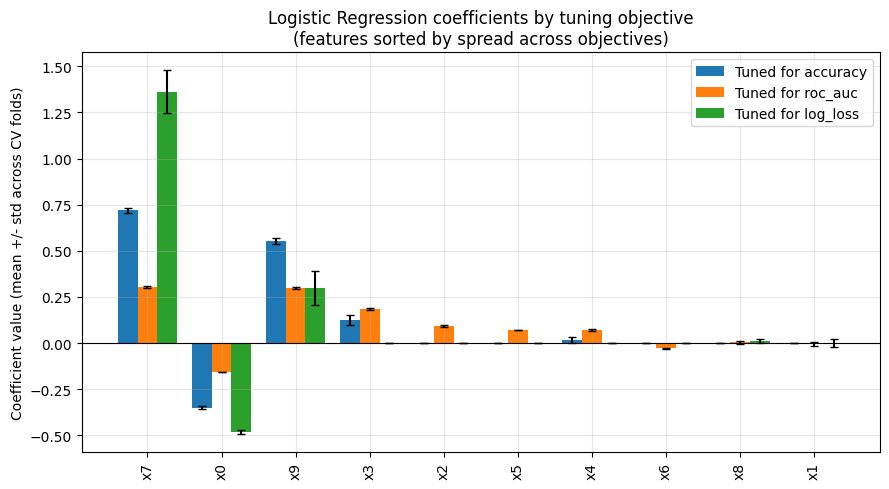

In [6]:
n_groups = len(scoring_metrics)
width = 0.8 / n_groups
x_pos = np.arange(len(coef_df))

fig, ax = plt.subplots(figsize=(9, 5))
for i, scoring in enumerate(scoring_metrics):
    name = display_name[scoring]
    offset = (i - (n_groups - 1) / 2) * width
    ax.bar(
        x_pos + offset, coef_df[f"coef_{name}_mean"], width,
        yerr=coef_df[f"coef_{name}_std"], capsize=3, label=f"Tuned for {name}",
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(coef_df["feature"], rotation=90)
ax.set_ylabel("Coefficient value (mean +/- std across CV folds)")
ax.set_title("Logistic Regression coefficients by tuning objective\n(features sorted by spread across objectives)")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Compare performance

All three tuned models scored with accuracy, ROC-AUC, and log loss on the same held-out test set.

In [7]:
performance = []

for scoring, search in tuned_models.items():
    y_pred = search.predict(X_test)
    y_proba = search.predict_proba(X_test)[:, 1]
    performance.append({
        "tuned_for": display_name[scoring],
        "accuracy": accuracy_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "log_loss": log_loss(y_test, y_proba),
    })

performance_df = pd.DataFrame(performance).set_index("tuned_for")
performance_df

,accuracy,roc_auc,log_loss
tuned_for,,,
accuracy,0.823333,0.834148,0.437821
roc_auc,0.802667,0.839077,0.463825
log_loss,0.820667,0.836042,0.436265
